[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Seminar%2001/Seminar%2000.ipynb)

In [1]:
#!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [3]:
# Define the stock ticker and time period
ticker = "AAPL"
start_date = "2020-01-01"
end_date = "2024-01-01"

In [4]:
# Download historical data
data = yf.download(ticker, start=start_date, end=end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [5]:
print(data)

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2020-01-02   72.716064   72.776591   71.466805   71.721011  135480400
2020-01-03   72.009132   72.771760   71.783977   71.941343  146322800
2020-01-06   72.582901   72.621639   70.876068   71.127858  118387200
2020-01-07   72.241562   72.849239   72.021246   72.592609  108872000
2020-01-08   73.403656   73.706287   71.943766   71.943766  132079200
...                ...         ...         ...         ...        ...
2023-12-22  192.444595  194.243791  191.818350  194.015153   37122800
2023-12-26  191.897873  192.732856  191.679185  192.454528   28919300
2023-12-27  191.997269  192.345186  189.949565  191.341219   48087700
2023-12-28  192.424713  193.498269  192.017156  192.981369   34049900
2023-12-29  191.380966  193.239801  190.585738  192.742785   42628800

[1006 rows x 5 colu

In [6]:
print(data.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [7]:
# Select the correct 'Close' price from the multi-index
price_column = ('Close', 'AAPL') if ('Close', 'AAPL') in data.columns else 'Close'

In [8]:
# Compute simple returns
data['Simple Return'] = data[price_column].pct_change()

In [9]:
# Compute logarithmic returns
data['Log Return'] = np.log(data[price_column] / data[price_column].shift(1))

In [10]:
# Drop NaN values
returns_data = data[['Simple Return', 'Log Return']].dropna()

In [11]:
# Compute descriptive statistics
descriptive_stats = returns_data.describe()

In [12]:
# Compute skewness and kurtosis
skewness = returns_data.skew()
kurtosis = returns_data.kurtosis()

In [13]:
# Display statistics
print("Descriptive Statistics:")
print(descriptive_stats)
print("\nSkewness:")
print(skewness)
print("\nKurtosis:")
print(kurtosis)

Descriptive Statistics:
Price  Simple Return   Log Return
Ticker                           
count    1005.000000  1005.000000
mean        0.001187     0.000963
std         0.021146     0.021137
min        -0.128647    -0.137708
25%        -0.009127    -0.009169
50%         0.000988     0.000988
75%         0.012743     0.012662
max         0.119808     0.113158

Skewness:
Price          Ticker
Simple Return            0.076564
Log Return              -0.141997
dtype: float64

Kurtosis:
Price          Ticker
Simple Return            4.881197
Log Return               4.993055
dtype: float64


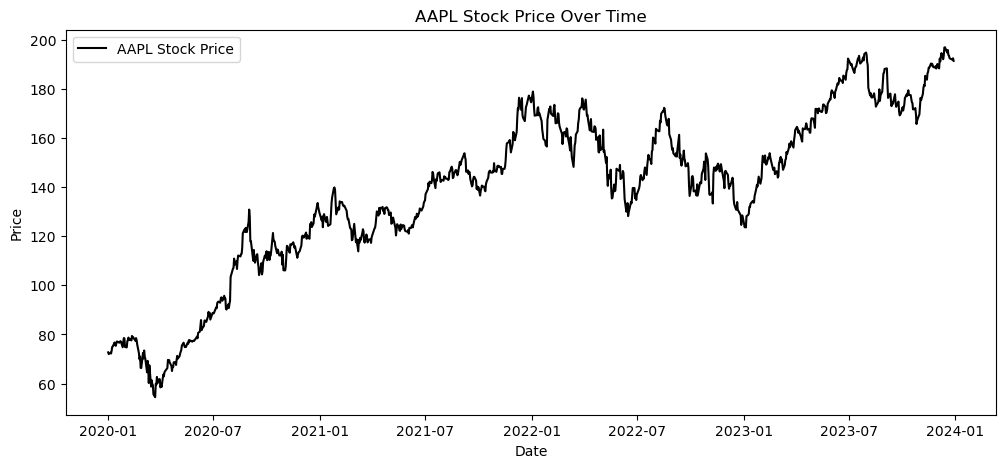

In [14]:
# Plot stock price
plt.figure(figsize=(12, 5))
plt.plot(data.index, data[price_column], label=f'{ticker} Stock Price', color='black')
plt.title(f'{ticker} Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

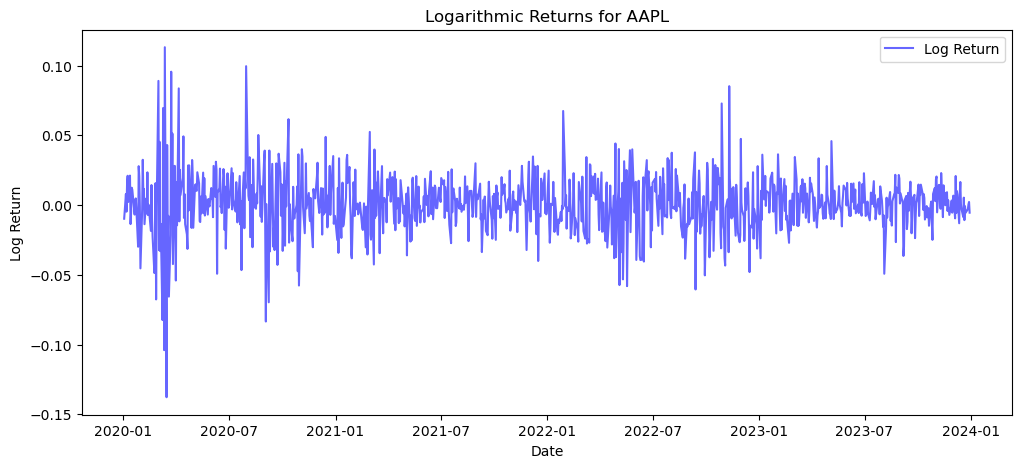

In [15]:
# Plot returns
plt.figure(figsize=(12, 5))
plt.plot(returns_data['Log Return'], label="Log Return", color='blue', alpha=0.6)
plt.title(f'Logarithmic Returns for {ticker}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.show()

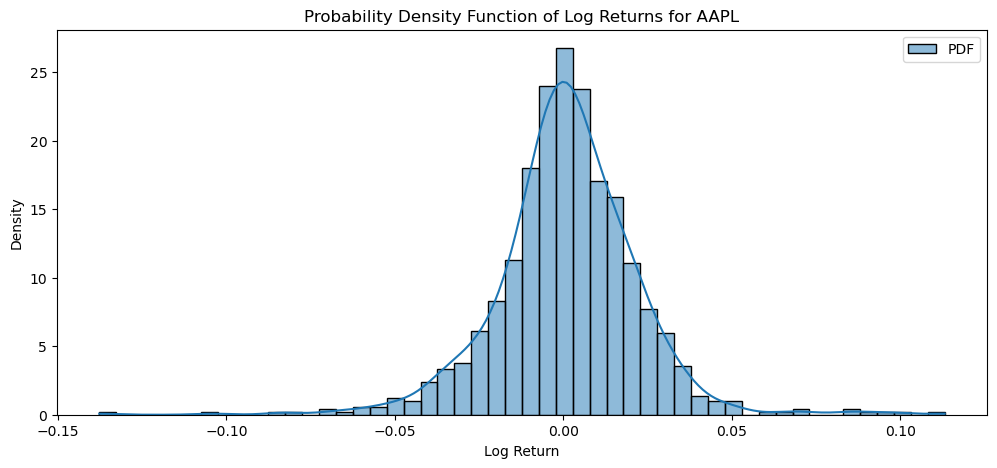

In [16]:
# Probability Density Function (PDF) and Cumulative Distribution Function (CDF)
plt.figure(figsize=(12, 5))
sns.histplot(returns_data['Log Return'], kde=True, stat="density", bins=50, label="PDF")
plt.title(f'Probability Density Function of Log Returns for {ticker}')
plt.xlabel('Log Return')
plt.ylabel('Density')
plt.legend()
plt.show()

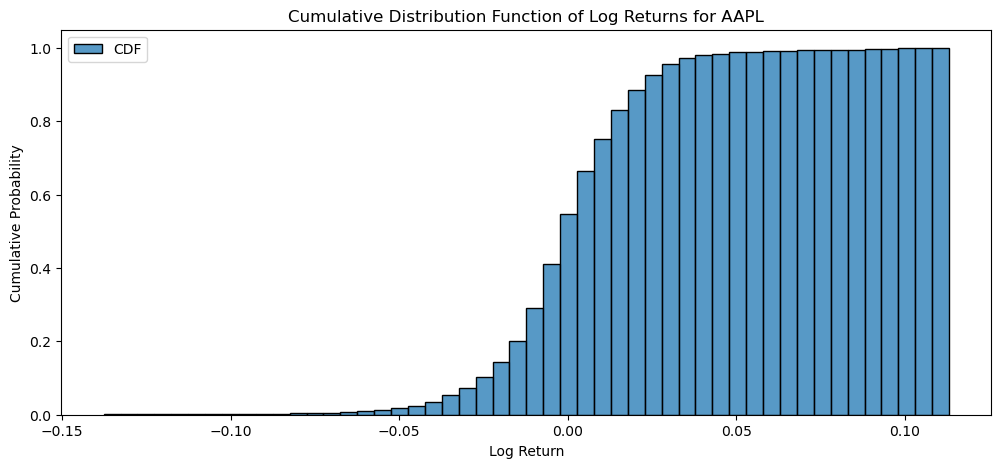

In [17]:
plt.figure(figsize=(12, 5))
sns.histplot(returns_data['Log Return'], cumulative=True, stat="density", bins=50, label="CDF")
plt.title(f'Cumulative Distribution Function of Log Returns for {ticker}')
plt.xlabel('Log Return')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

In [18]:
# Save data to CSV
returns_data.to_csv("stock_returns.csv")

print("Data saved to 'stock_returns.csv'")

Data saved to 'stock_returns.csv'
